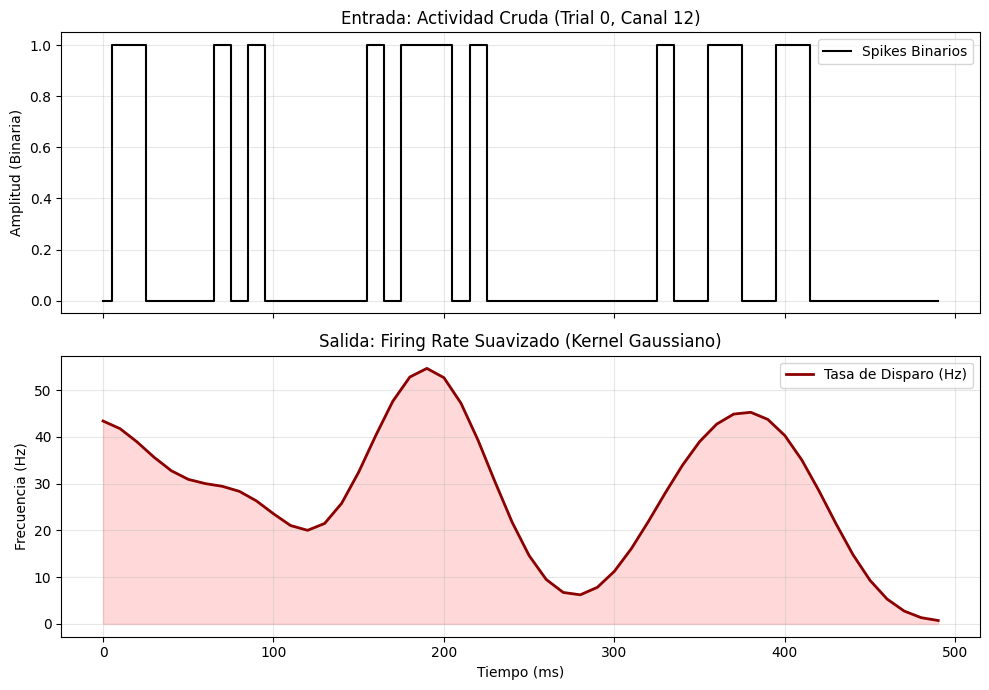

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Parámetros de visualización (Trial 0, Neurona 12)
t_idx = 0
n_idx = 12
time_ms = np.arange(time_bins) * 10

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Señal Original: Binaria
ax1.step(time_ms, X_train_raw[t_idx, :, n_idx], color='black', where='mid', label='Spikes Binarios')
ax1.set_title(f'Entrada: Actividad Cruda (Trial {t_idx}, Canal {n_idx})')
ax1.set_ylabel('Amplitud (Binaria)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Señal Procesada: Continua
ax2.plot(time_ms, X_train_smoothed[t_idx, :, n_idx], color='darkred', linewidth=2, label='Tasa de Disparo (Hz)')
ax2.fill_between(time_ms, X_train_smoothed[t_idx, :, n_idx], color='red', alpha=0.15)
ax2.set_title('Salida: Firing Rate Suavizado (Kernel Gaussiano)')
ax2.set_xlabel('Tiempo (ms)')
ax2.set_ylabel('Frecuencia (Hz)')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2284/1467580772.py:21: SyntaxWarning: invalid escape sequence '\s'
  plt.title('Después: Tasa de Disparo Suavizada (Filtro Gaussiano $\sigma=30ms$)')


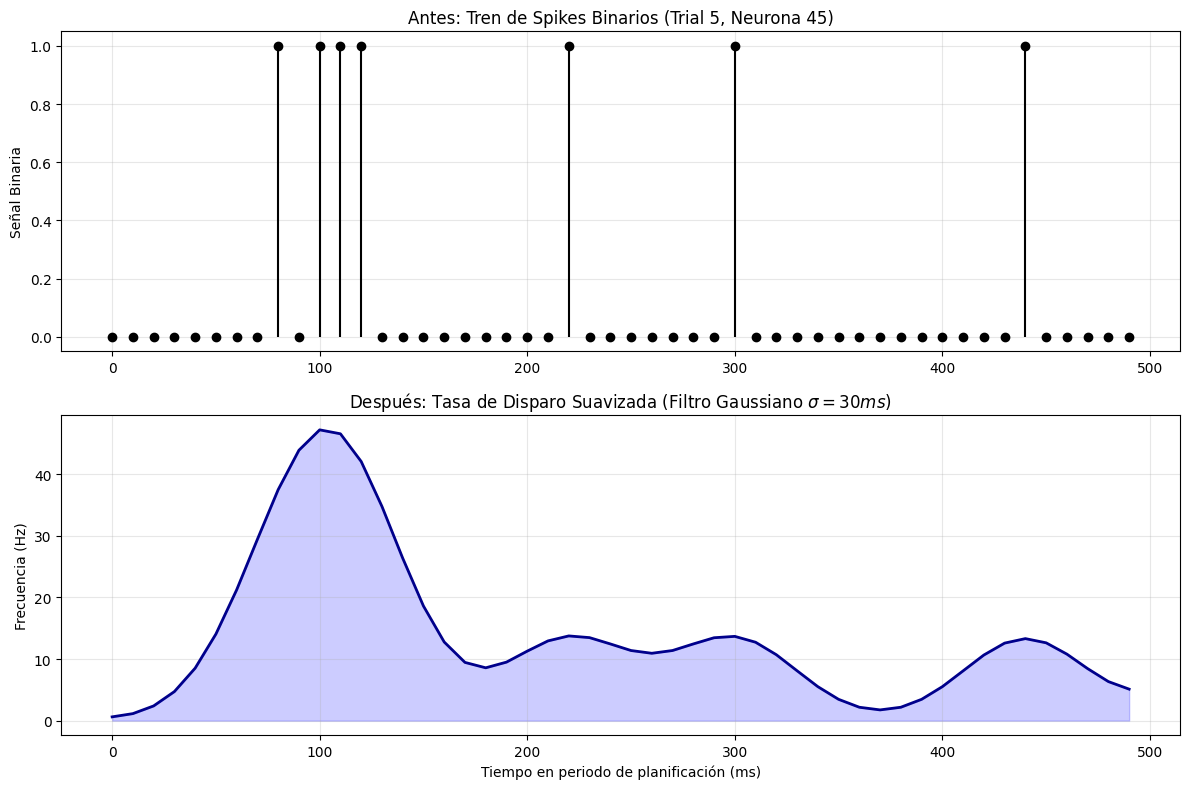

In [ ]:
import seaborn as sns

# --- Gráfica Comparativa: Antes vs Después ---
plt.figure(figsize=(12, 8))

trial_to_show = 5
neuron_to_show = 45
time_ms = np.arange(time_bins) * 10

# Original (Antes)
plt.subplot(2, 1, 1)
plt.stem(time_ms, X_train_raw[trial_to_show, :, neuron_to_show], linefmt='k-', markerfmt='ko', basefmt=' ')
plt.title(f'Antes: Tren de Spikes Binarios (Trial {trial_to_show}, Neurona {neuron_to_show})')
plt.ylabel('Señal Binaria')
plt.grid(True, alpha=0.3)

# Procesado (Después)
plt.subplot(2, 1, 2)
plt.plot(time_ms, X_train_smoothed[trial_to_show, :, neuron_to_show], color='darkblue', linewidth=2)
plt.fill_between(time_ms, X_train_smoothed[trial_to_show, :, neuron_to_show], alpha=0.2, color='blue')
plt.title('Después: Tasa de Disparo Suavizada (Filtro Gaussiano $\sigma=30ms$)')
plt.xlabel('Tiempo en periodo de planificación (ms)')
plt.ylabel('Frecuencia (Hz)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2284/3535903964.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis', ax=ax1, edgecolor='black')


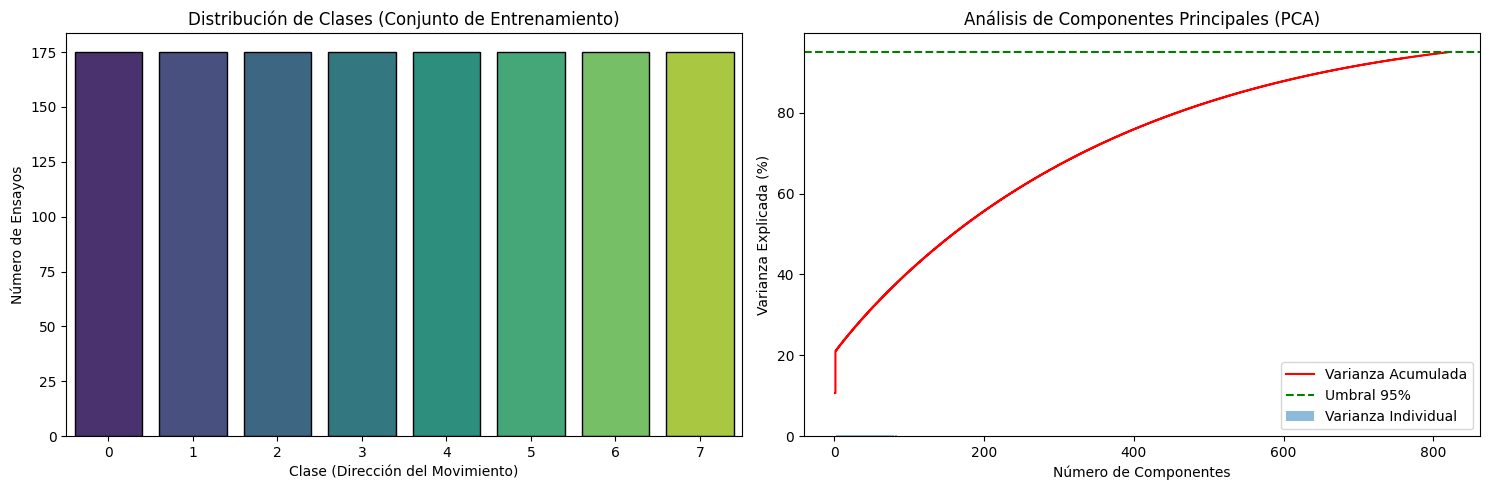

In [ ]:
# --- Gráfica de Balance de Clases y Varianza ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Balance de Clases
sns.countplot(x=y_train, palette='viridis', ax=ax1, edgecolor='black')
ax1.set_title('Distribución de Clases (Conjunto de Entrenamiento)')
ax1.set_xlabel('Clase (Dirección del Movimiento)')
ax1.set_ylabel('Número de Ensayos')

# Varianza PCA
exp_var = pca.explained_variance_ratio_ * 100
cum_var = np.cumsum(exp_var)
ax2.step(range(1, len(cum_var) + 1), cum_var, where='mid', label='Varianza Acumulada', color='red')
ax2.bar(range(1, len(exp_var) + 1), exp_var, alpha=0.5, align='center', label='Varianza Individual')
ax2.axhline(y=95, color='green', linestyle='--', label='Umbral 95%')
ax2.set_title('Análisis de Componentes Principales (PCA)')
ax2.set_xlabel('Número de Componentes')
ax2.set_ylabel('Varianza Explicada (%)')
ax2.legend(loc='best')

plt.tight_layout()
plt.show()